# Boston Housing - EDA et Prédiction de MEDV avec XGBoost

Notebook complet : exploration des données, statistiques descriptives, visualisations, corrélations, entraînement et évaluation du modèle XGBoost.

In [1]:
pip install pandas numpy scikit-learn xgboost matplotlib seaborn

     ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
     ------------------------------------ - 286.7/294.9 kB 6.0 MB/s eta 0:00:01
     -------------------------------------- 294.9/294.9 kB 3.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_style('whitegrid')

In [3]:
# Chargement des données
DATA_URL='https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv'
housing_data=pd.read_csv(DATA_URL)
print(housing_data.head())
print('Dimensions :', housing_data.shape)

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  
Dimensions : (506, 14)


In [5]:
# Informations générales
print(housing_data.info())
print('Valeurs manquantes :')
print(housing_data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
None
Valeurs manquantes :
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [7]:
# Statistiques descriptives
print(housing_data.describe())

print('Minimums :')
print(housing_data.min())

print('Maximums :')
print(housing_data.max())

             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              age         dis         rad         tax     ptratio           b  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

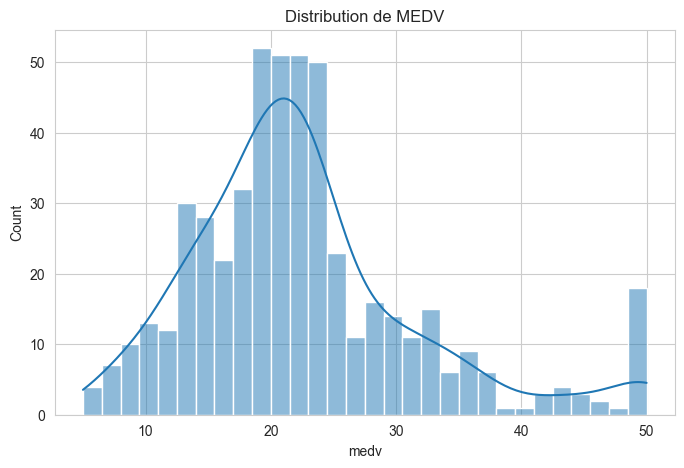

In [8]:
# Distribution de la variable cible
plt.figure(figsize=(8,5))
sns.histplot(housing_data['medv'], bins=30, kde=True)
plt.title('Distribution de MEDV')
plt.show()

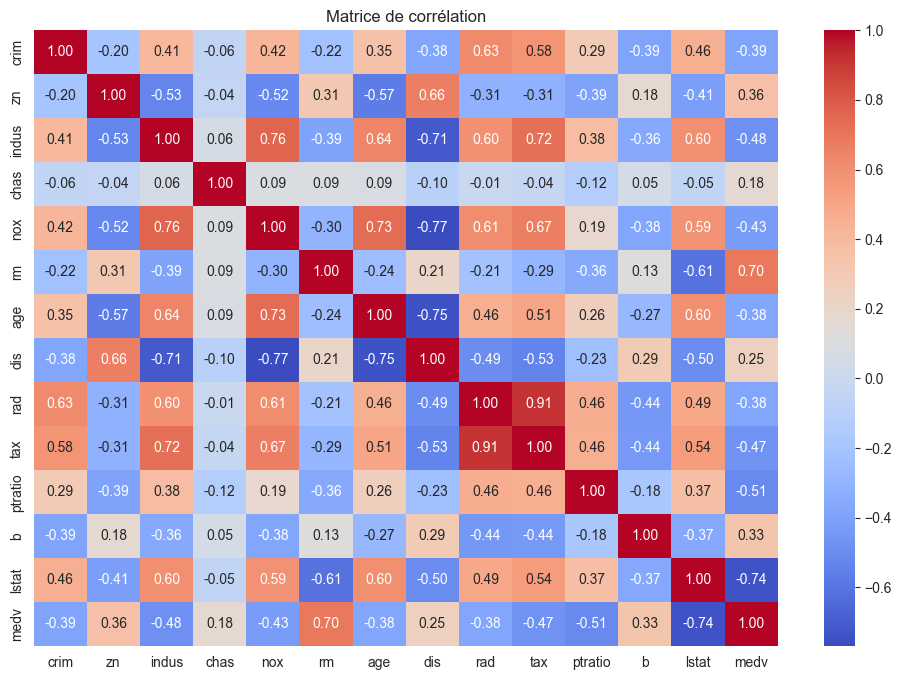

medv       1.000000
rm         0.695360
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64


In [9]:
# Corrélations
corr_matrix=housing_data.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,cmap='coolwarm',annot=True,fmt='.2f')
plt.title('Matrice de corrélation')
plt.show()

print(corr_matrix['medv'].sort_values(ascending=False))

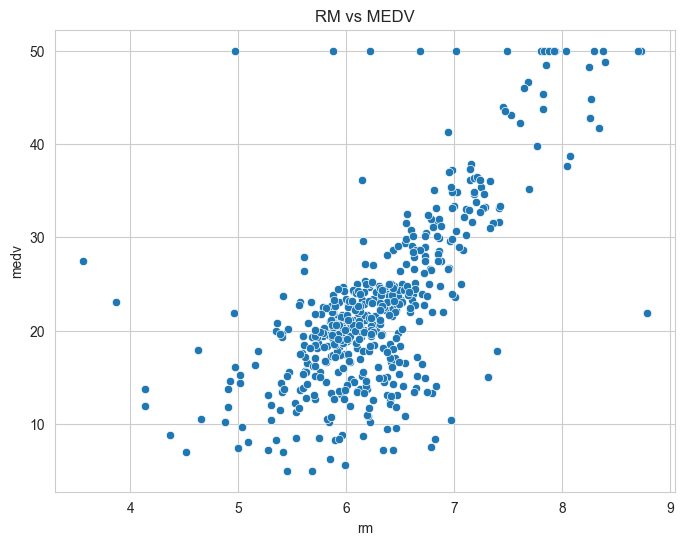

In [10]:
# Relation RM vs MEDV
plt.figure(figsize=(8,6))
sns.scatterplot(data=housing_data,x='rm',y='medv')
plt.title('RM vs MEDV')
plt.show()

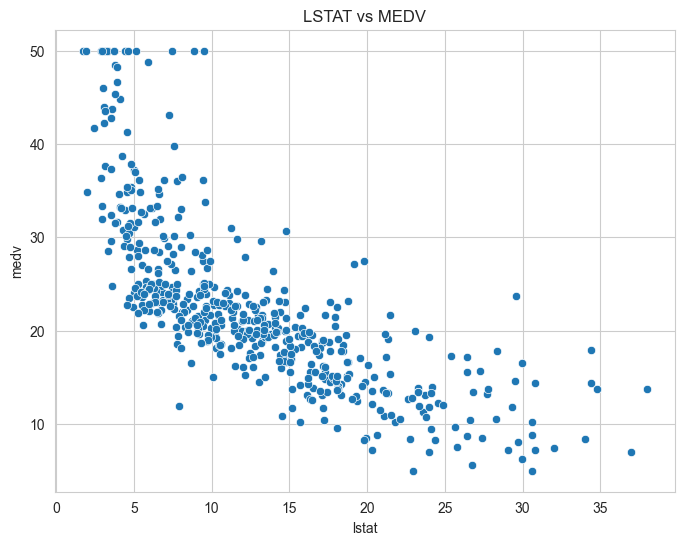

In [11]:
# Relation LSTAT vs MEDV
plt.figure(figsize=(8,6))
sns.scatterplot(data=housing_data,x='lstat',y='medv')
plt.title('LSTAT vs MEDV')
plt.show()

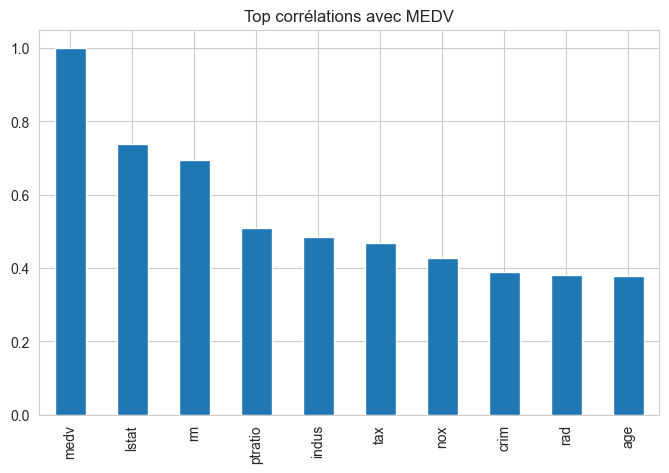

In [12]:
# Top corrélations avec MEDV
corr_medv=housing_data.corr(numeric_only=True)['medv'].abs().sort_values(ascending=False)
plt.figure(figsize=(8,5))
corr_medv.head(10).plot(kind='bar')
plt.title('Top corrélations avec MEDV')
plt.show()

In [13]:
# Préparation des données
y=housing_data['medv']
X=housing_data.drop('medv',axis=1)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
# Entraînement XGBoost
model=XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=4,subsample=0.8,colsample_bytree=0.8,random_state=42)
model.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [15]:
# Prédictions et métriques
y_pred=model.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=mse**0.5
r2=r2_score(y_test,y_pred)
print(f'MAE : {mae:.3f}')
print(f'MSE : {mse:.3f}')
print(f'RMSE : {rmse:.3f}')
print(f'R2 : {r2:.3f}')

MAE : 1.762
MSE : 6.197
RMSE : 2.489
R2 : 0.915


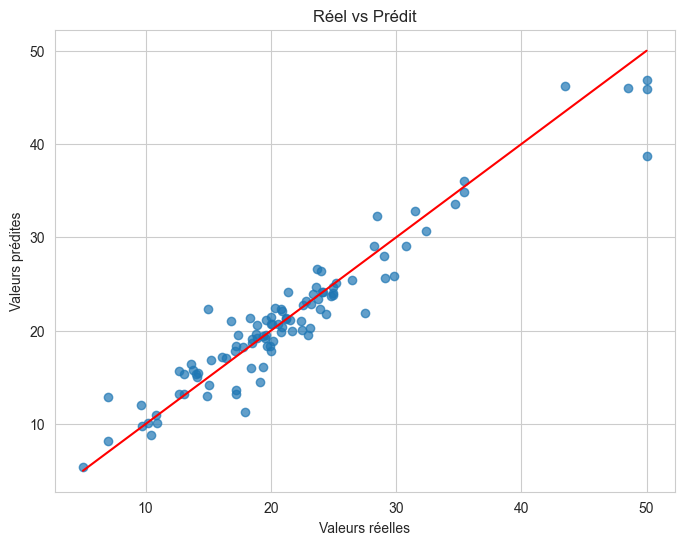

In [16]:
# Comparaison réel vs prédit
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred,alpha=0.7)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],color='red')
plt.xlabel('Valeurs réelles')
plt.ylabel('Valeurs prédites')
plt.title('Réel vs Prédit')
plt.show()

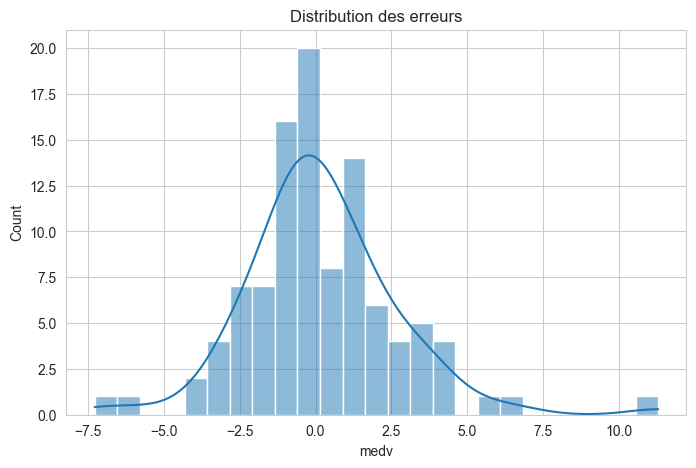

In [17]:
# Distribution des erreurs
errors=y_test-y_pred
plt.figure(figsize=(8,5))
sns.histplot(errors,bins=25,kde=True)
plt.title('Distribution des erreurs')
plt.show()

   Variable  Importance
12    lstat    0.332942
5        rm    0.275652
10  ptratio    0.078782
4       nox    0.058085
7       dis    0.056698
9       tax    0.045771
0      crim    0.043601
8       rad    0.024427
3      chas    0.018411
6       age    0.018063
2     indus    0.017947
11        b    0.016668
1        zn    0.012953


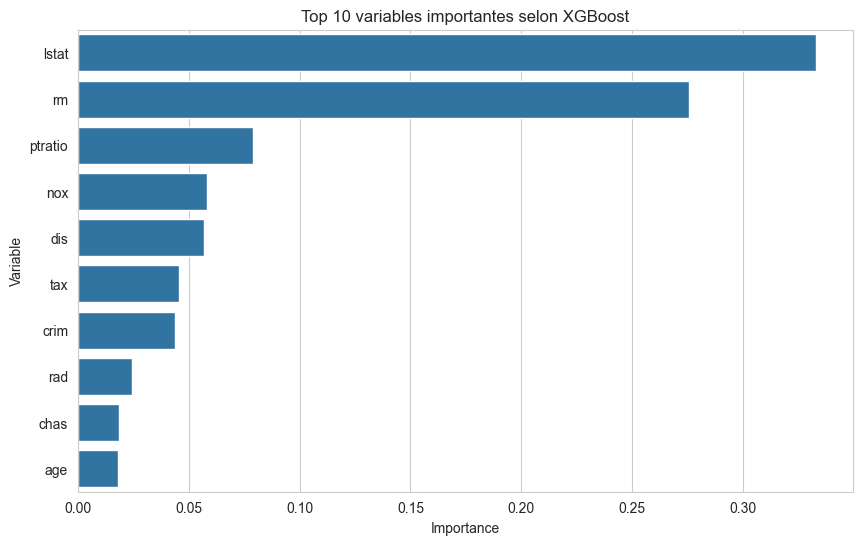

In [18]:
# Importance des variables
feature_importance=pd.DataFrame({'Variable':X.columns,'Importance':model.feature_importances_}).sort_values('Importance',ascending=False)
print(feature_importance)
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(10),x='Importance',y='Variable')
plt.title('Top 10 variables importantes selon XGBoost')
plt.show()

In [19]:
# Exemples de prédictions
results=pd.DataFrame({'Valeur réelle':y_test.values,'Valeur prédite':y_pred})
print(results.head(10))

   Valeur réelle  Valeur prédite
0           23.6       24.674843
1           32.4       30.696371
2           13.6       16.449965
3           22.8       23.172766
4           16.1       17.190054
5           20.0       21.446112
6           17.8       18.289673
7           14.0       15.389042
8           19.6       21.178860
9           16.8       21.032864
